## LLM 生成題庫, 理想題庫(問答對), 及應用(評估系統回答能力)
* ### assign LLM
* ### get 特定 Vector DB
* ### 理想答案, LLM 生成問答對(題庫), 建立, 儲存...
* ### 評估系統/Model能力(langchain LLM 評估, RAGAS 評估)

### Assign Basic LLM Models

In [6]:
import warnings
warnings.filterwarnings('ignore')

* ### OpenAI

In [5]:
import os
import openai
import sys
sys.path.append('../..')

from dotenv import load_dotenv, find_dotenv
_ = load_dotenv(find_dotenv()) # read local .env file

openai.api_key  = os.environ['OPENAI_API_KEY']

In [3]:
# account for deprecation of LLM model
import datetime
# Get the current date
current_date = datetime.datetime.now().date()

# Define the date after which the model should be set to "gpt-3.5-turbo"
target_date = datetime.date(2024, 6, 12)

# Set the model variable based on the current date
if current_date > target_date:
    llm_model = "gpt-3.5-turbo-0301"
else:
    llm_model = "gpt-3.5-turbo"
    
llm_model

'gpt-3.5-turbo'

In [ ]:
## assign OpenAI Model
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(temperature=0.9, model=llm_model)

## LLM-Generated examples, LLM 生成問答對+理想答案+AI 生成舊問答對(人工check)
* ### 系統建置時使用, 非運行時的評估

* ## I. Human標準問答對(題庫)建立

In [1]:
## 1.建立標準問答對組合, (也可用 CSV, SQL...)
# 提問
eval_queries = [
    "哪邊可以拿到預立醫療決定的表格？是不是簽名就可以？",
    "任何人都可以進行「預立醫療照護諮商」 及「預立醫療決定」嗎？",
    "我想帶我媽去參加預立醫療決定諮商，我要怎麼跟她說？",
    "我爸中風7年了，在養護中心可以簽預立醫療決定嗎？",
    "預立醫療照護諮商需要多久時間呢？",
    "兩位或兩位以上的意願人能否在同一次諮商中，一起完成預立醫療照護諮商？",
    "做了「預立醫療決定」後，是否發生明明還有治癒機會，或遭逢意外，卻被醫師提前放棄治療的情況？",
    "「預立醫療決定書」上傳註記後還能修改嗎？",
    "預立醫療決定書上為什麼需要見證人？",
    "誰可以擔任見證人？(外籍看護可以嗎？)",
    "誰不能擔任見證人？",
    "見證人要擔負什麼責任？",
    "如果沒有見證人，可以怎麼做？",
    "聽說預立醫療決定還要找見證人，所以我要找到見證人一起去醫院做預立醫療照護諮商嗎？",
    "做完預立醫療照護諮商(ACP)後，一定要填寫預立醫療決定書(AD)嗎？一定要當下完成並繳回嗎？",
    "拒絕人工營養及流體餵養，那是要將病人餓死、渴死嗎？",
    "如果我的二親等有事無法到門診參加預立醫療諮商，該怎麼辦？",    
]

# 理想答案(對應以上的位置))
eval_answers = [
    "提供AD網站簽署前也必須與醫療團隊共同進行「預立醫療照護諮商」會議，討論各項醫療選項的成效與風險，透過溝通與決策過程，以書面形式完成您的「預立醫療決定」。另外，還需完成健保IC卡註記，您的「預立醫療決定」才具法律效力。", 
    "滿20歲具有完全行為能力者皆可，只要您： \
    1.至醫療機構完成「預立醫療照護諮商」，並經兩人以上在場見證或公證程序。\
    2.完成健保IC卡註記，您的「預立醫療決定」即具有法律效力。",
    "您可透過新聞報導、社會重大事件等話題，試著在聊天中找到討論時機，先聊聊自己對生命與死亡之體悟，鼓勵媽媽分享她的感受及想法，觀察媽媽反應。若媽媽不排斥，願意表達所期待的醫療照顧或身心靈需求，則可邀請她參加「預立醫療照護諮商」；並請告訴她，這是由醫師、護理師、社工師組成的諮商團隊，提供醫療、社會、家庭與心理的討論；諮商過後不一定要簽署「預立醫療決定」，但可透過諮商過程，讓媽媽有機會更清楚的思考與表達想法，也讓您有機會事先瞭解媽媽的期待。", 
    "原則上只要您的父親意識清楚且可以表達意願，以及在沒有心智缺陷或非出於自願的疑慮下，是可以邀請二親等家屬或醫療委任代理人，共同參與預立醫療照護諮商及簽署預立醫療決定的。", 
    "為了說明預立醫療意願書內涵並意願人的想法，推估約要半小時到一小時。", 
    "若當意願人及其家屬為彼此的二等親及醫療委任代理人，是可以一同完成預立醫療照護諮商。",
    "不會。須經由二位具相關專科醫師資格之醫師確診已符合條文所明定之臨床條件，並經緩和醫療團隊至少二次照會，才可執行預立醫療決定，不符合臨床條件者，應先予適當急救或採取必要措施，不得無故拖延；其過程非常謹慎，且經重重把關，不可能因立下預立醫療決定，而讓原有治癒機會的患者因而被提前放棄治療。",
    "意願人想撤回或變更預立醫療決定時，需要重新簽署預立醫療決定書，並向中央主管機關申請更新註記。",
    "為了保障個人簽署預立醫療決定書是出於自願、並無遭受外力脅迫等情況所決定。",
    "見證人除了不是意願人所指定之醫療委任代理人、主責照護醫療團隊成員、以及繼承人之外的受遺贈人、遺體或器官指定之受贈人、其他因意願人死亡而獲得利益者，剩下的人都可以擔任見證人。",
    "意願人所指定之醫療委任代理人、主責照護醫療團隊成員、以及繼承人之外的受遺贈人、遺體或器官指定之受贈人、其他因意願人死亡而獲得利益者，都不能擔任見證人。",
    "見證意願人簽署當下意識清楚、出於自願未受脅迫下簽署；不涉及醫療決策。",
    "可以找公證人。", 
    "不一定。病人自主權利法規定在預立醫療決定上簽名時有二名以上滿20歲具完全行為能力人在場見證或經公證人公證即可。若您的親友無法擔任見證人，您可事先告知醫療機構，有些機構或許協助安排。請特別注意，您的醫療委任代理人是無法做見證人。",
    "來參加ACP不一定要簽署AD喔。能與自己跟親友一起思考、探索生命議題的過程很有意義。您的醫療決定必須讓家人知道，才能當你意識不清的時候幫你實現。",
    "不是的！還可以慢慢從口餵食啊，過多水份養分其實造成額外負擔，末期病人並不會感到飢餓，餵食反而會造成嘔吐、食物進入氣管造成窒息等後果，若病人無法配合，掙扎甚至四肢約束、強迫裝置鼻胃管進行人工管灌，反更加痛苦。",
    "可以使用視訊參與預立醫療諮商，與醫療團隊共同了解您對生命真實想法與期待，確保預立醫療決定的實踐。",
]

## 2. built idea answers pair...
ideaAnswers = [
    {"query": q, "answer": eval_answers[i]}
      for i, q in enumerate(eval_queries)
]

len(eval_queries), len(eval_answers)

(17, 17)

In [11]:
## 3. 理想答案 save to CSV for future use
import pandas as pd

columns = ['Question', 'Answer', 'Remark']

# 使用 pd.DataFrame() 建立 DataFrame
df_H = pd.DataFrame(columns=columns)

for i in range(0, len(ideaAnswers)):
     df_H.loc[i]= [ideaAnswers[i]["query"], ideaAnswers[i]["answer"], "Human"]

# 將 DataFrame 寫入 CSV 檔案
df_H.to_csv("Human_QA.csv", index=False)     # index=False 避免寫入索引列        
        
#df_H 

,Question,Answer,Remark
0,哪邊可以拿到預立醫療決定的表格？是不是簽名就可以？,提供AD網站簽署前也必須與醫療團隊共同進行「預立醫療照護諮商」會議，討論各項醫療選項的成效與風險，透過溝通與決策過程，以書面形式完成您的「預立醫療決定」。另外，還需完成健保IC卡註記，您的「預立醫療決定」才具法律效力。,Human
1,任何人都可以進行「預立醫療照護諮商」 及「預立醫療決定」嗎？,滿20歲具有完全行為能力者皆可，只要您： 1.至醫療機構完成「預立醫療照護諮商」，並經兩人以上在場見證或公證程序。 2.完成健保IC卡註記，您的「預立醫療決定」即具有法律效力。,Human
2,我想帶我媽去參加預立醫療決定諮商，我要怎麼跟她說？,您可透過新聞報導、社會重大事件等話題，試著在聊天中找到討論時機，先聊聊自己對生命與死亡之體悟，鼓勵媽媽分享她的感受及想法，觀察媽媽反應。若媽媽不排斥，願意表達所期待的醫療照顧或身心靈需求，則可邀請她參加「預立醫療照護諮商」；並請告訴她，這是由醫師、護理師、社工師組成的諮商團隊，提供醫療、社會、家庭與心理的討論；諮商過後不一定要簽署「預立醫療決定」，但可透過諮商過程，讓媽媽有機會更清楚的思考與表達想法，也讓您有機會事先瞭解媽媽的期待。,Human
3,我爸中風7年了，在養護中心可以簽預立醫療決定嗎？,原則上只要您的父親意識清楚且可以表達意願，以及在沒有心智缺陷或非出於自願的疑慮下，是可以邀請二親等家屬或醫療委任代理人，共同參與預立醫療照護諮商及簽署預立醫療決定的。,Human
4,預立醫療照護諮商需要多久時間呢？,為了說明預立醫療意願書內涵並意願人的想法，推估約要半小時到一小時。,Human
5,兩位或兩位以上的意願人能否在同一次諮商中，一起完成預立醫療照護諮商？,若當意願人及其家屬為彼此的二等親及醫療委任代理人，是可以一同完成預立醫療照護諮商。,Human
6,做了「預立醫療決定」後，是否發生明明還有治癒機會，或遭逢意外，卻被醫師提前放棄治療的情況？,不會。須經由二位具相關專科醫師資格之醫師確診已符合條文所明定之臨床條件，並經緩和醫療團隊至少二次照會，才可執行預立醫療決定，不符合臨床條件者，應先予適當急救或採取必要措施，不得無故拖延；其過程非常謹慎，且經重重把關，不可能因立下預立醫療決定，而讓原有治癒機會的患者因而被提前放棄治療。,Human
7,「預立醫療決定書」上傳註記後還能修改嗎？,意願人想撤回或變更預立醫療決定時，需要重新簽署預立醫療決定書，並向中央主管機關申請更新註記。,Human
8,預立醫療決定書上為什麼需要見證人？,為了保障個人簽署預立醫療決定書是出於自願、並無遭受外力脅迫等情況所決定。,Human
9,誰可以擔任見證人？(外籍看護可以嗎？),見證人除了不是意願人所指定之醫療委任代理人、主責照護醫療團隊成員、以及繼承人之外的受遺贈人、遺體或器官指定之受贈人、其他因意願人死亡而獲得利益者，剩下的人都可以擔任見證人。,Human


* ## II. AI 生成問答對
* ### 逐頁生成new LLM examples(問答對)

In [3]:
## 1.取得 vector db ###
from langchain.vectorstores import Chroma
from langchain_openai import OpenAIEmbeddings
from langchain_community.embeddings import HuggingFaceEmbeddings

#embedding = OpenAIEmbeddings()
embedding = HuggingFaceEmbeddings()    

persist_directory = "../Data_test/VectorDB/預立醫療txt"  ## 注意位置是否正確

vectordb = Chroma(
    persist_directory=persist_directory,
    embedding_function=embedding
)

##取出所有 splits_doc, 需事先核對之
k = 1000
splits_doc = vectordb.similarity_search("", k = k)

len(splits_doc)

Number of requested results 1000 is greater than number of elements in index 711, updating n_results = 711


711

In [7]:
## 2.LLM 生成問答對, 即時隨機生成 for 模型測試
from langchain.evaluation.qa import QAGenerateChain
from langchain_openai import ChatOpenAI

##取出所有 splits_doc, 需事先核對之或設定一個極大值
splits_doc = vectordb.similarity_search("", k = 711)

## 經修改原package所在位置的prompttemplate後可以輸出繁體中文
example_gen_chain = QAGenerateChain.from_llm(ChatOpenAI(model="gpt-3.5-turbo"))

## 隨機生成examples(問答對), 逐頁生成答案
import random

k = 3                                                                                  ## 生成問答對的數量   
#random_integers = [random.randint(0, len(splits_doc)) for _ in range(num_integers)]   ## 隨機整數, 但數值可能重複...
random_integers = random.sample(range(len(splits_doc)), k)                             ## range, 以及產生k個隨機整數
                                  
llm_examples = []
for i in random_integers:                                                            
    llm_examples_i = example_gen_chain.apply_and_parse(
        [{"doc": t} for t in splits_doc[i:i+1]]
    )
    ## Combine examples
    llm_examples += llm_examples_i

# 須從'qa_pairs'取出資料, 
llm_examples = [item['qa_pairs'] for item in llm_examples]

#llm_examples

In [8]:
llm_examples

[{'query': '根據文件中的資訊，民國113年03月15日的瀏覽人次總計為多少人？',
  'answer': '民國113年03月15日的瀏覽人次總計為1,192,286,766人。'},
 {'query': '什麼是「接受自然死亡（AND）」？這種方法適用於哪類病人？',
  'answer': '「接受自然死亡（AND）」是指對於已達疾病末期的病人，不再採取任何延後死亡的治療措施，讓病人在家人陪伴下自然離開世界。這種方法適用於已無治癒效果，只能延長瀕死過程的末期病人。'},
 {'query': '在這份文件中，應填寫的出生年月日是多少？並提供相應的空格填寫格式。',
  'answer': '出生年月日應填寫為中華民國 ________ 年 ________ 月 ________ 日。'}]

In [9]:
## 3.將LLM 生成答案存檔, 可check, 修改, 再成為理想答案

import pandas as pd
pd.set_option('display.max_colwidth', None)

columns = ['Question', 'Answer', 'Suggestion', 'Remark']

# 使用 pd.DataFrame() 建立 DataFrame
df_LLM = pd.DataFrame(columns=columns)

for i in range(0, len(llm_examples)):
     df_LLM.loc[i]= [llm_examples[i]["query"], llm_examples[i]["answer"], "", "AI"]

df_LLM

# 將 DataFrame 寫入 CSV 檔案
df_LLM.to_csv("LLM_QA.csv", index=False)     # index=False 避免寫入索引列

In [10]:
import pandas as pd
pd.set_option('display.max_colwidth', None)

# 從 CSV 讀取LLM生成問答對資料到 DataFrame
df_LLM = pd.read_csv("LLM_QA.csv")

df_LLM

,Question,Answer,Suggestion,Remark
0,根據文件中的資訊，民國113年03月15日的瀏覽人次總計為多少人？,"民國113年03月15日的瀏覽人次總計為1,192,286,766人。",NaN,AI
1,什麼是「接受自然死亡（AND）」？這種方法適用於哪類病人？,「接受自然死亡（AND）」是指對於已達疾病末期的病人，不再採取任何延後死亡的治療措施，讓病人在家人陪伴下自然離開世界。這種方法適用於已無治癒效果，只能延長瀕死過程的末期病人。,NaN,AI
2,在這份文件中，應填寫的出生年月日是多少？並提供相應的空格填寫格式。,出生年月日應填寫為中華民國 ________ 年 ________ 月 ________ 日。,NaN,AI


* #### 從CSV/dataframe 取出問答對

In [12]:
## check 理想答案...
import pandas as pd
pd.set_option('display.max_colwidth', None)

# 從 CSV 讀取理想答案資料到 DataFrame
df_H = pd.read_csv("Human_QA.csv")

#df_H

,Question,Answer,Remark
0,哪邊可以拿到預立醫療決定的表格？是不是簽名就可以？,提供AD網站簽署前也必須與醫療團隊共同進行「預立醫療照護諮商」會議，討論各項醫療選項的成效與風險，透過溝通與決策過程，以書面形式完成您的「預立醫療決定」。另外，還需完成健保IC卡註記，您的「預立醫療決定」才具法律效力。,Human
1,任何人都可以進行「預立醫療照護諮商」 及「預立醫療決定」嗎？,滿20歲具有完全行為能力者皆可，只要您： 1.至醫療機構完成「預立醫療照護諮商」，並經兩人以上在場見證或公證程序。 2.完成健保IC卡註記，您的「預立醫療決定」即具有法律效力。,Human
2,我想帶我媽去參加預立醫療決定諮商，我要怎麼跟她說？,您可透過新聞報導、社會重大事件等話題，試著在聊天中找到討論時機，先聊聊自己對生命與死亡之體悟，鼓勵媽媽分享她的感受及想法，觀察媽媽反應。若媽媽不排斥，願意表達所期待的醫療照顧或身心靈需求，則可邀請她參加「預立醫療照護諮商」；並請告訴她，這是由醫師、護理師、社工師組成的諮商團隊，提供醫療、社會、家庭與心理的討論；諮商過後不一定要簽署「預立醫療決定」，但可透過諮商過程，讓媽媽有機會更清楚的思考與表達想法，也讓您有機會事先瞭解媽媽的期待。,Human
3,我爸中風7年了，在養護中心可以簽預立醫療決定嗎？,原則上只要您的父親意識清楚且可以表達意願，以及在沒有心智缺陷或非出於自願的疑慮下，是可以邀請二親等家屬或醫療委任代理人，共同參與預立醫療照護諮商及簽署預立醫療決定的。,Human
4,預立醫療照護諮商需要多久時間呢？,為了說明預立醫療意願書內涵並意願人的想法，推估約要半小時到一小時。,Human
5,兩位或兩位以上的意願人能否在同一次諮商中，一起完成預立醫療照護諮商？,若當意願人及其家屬為彼此的二等親及醫療委任代理人，是可以一同完成預立醫療照護諮商。,Human
6,做了「預立醫療決定」後，是否發生明明還有治癒機會，或遭逢意外，卻被醫師提前放棄治療的情況？,不會。須經由二位具相關專科醫師資格之醫師確診已符合條文所明定之臨床條件，並經緩和醫療團隊至少二次照會，才可執行預立醫療決定，不符合臨床條件者，應先予適當急救或採取必要措施，不得無故拖延；其過程非常謹慎，且經重重把關，不可能因立下預立醫療決定，而讓原有治癒機會的患者因而被提前放棄治療。,Human
7,「預立醫療決定書」上傳註記後還能修改嗎？,意願人想撤回或變更預立醫療決定時，需要重新簽署預立醫療決定書，並向中央主管機關申請更新註記。,Human
8,預立醫療決定書上為什麼需要見證人？,為了保障個人簽署預立醫療決定書是出於自願、並無遭受外力脅迫等情況所決定。,Human
9,誰可以擔任見證人？(外籍看護可以嗎？),見證人除了不是意願人所指定之醫療委任代理人、主責照護醫療團隊成員、以及繼承人之外的受遺贈人、遺體或器官指定之受贈人、其他因意願人死亡而獲得利益者，剩下的人都可以擔任見證人。,Human


* ## III. 建立評估用範例(examples)

In [13]:
import random

## built QA examples from dataframe...

# from LLM
k= len(df_LLM)-1                                                      ## 隨機數的個數, 此處全取  
random_integers = random.sample(range(len(df_LLM)), k)                ## range, 以及產生隨機整數 list

examples_LLM = [
    {"query": df_LLM.iloc[i]["Question"], "answer": df_LLM.iloc[i]["Answer"]
}
    for i in random_integers
]

# from Human idea answer
k= 10                                                                 ## 隨機數的個數, 此處10個  
random_ints = random.sample(range(len(df_H)), k)                      ## range, 以及產生隨機整數 list
examples_H = [
    {"query": df_H.iloc[i]["Question"], "answer": df_H.iloc[i]["Answer"]
}
    for i in random_ints
]

examples = examples_LLM + examples_H + llm_examples

examples

[{'query': '什麼是「接受自然死亡（AND）」？這種方法適用於哪類病人？',
  'answer': '「接受自然死亡（AND）」是指對於已達疾病末期的病人，不再採取任何延後死亡的治療措施，讓病人在家人陪伴下自然離開世界。這種方法適用於已無治癒效果，只能延長瀕死過程的末期病人。'},
 {'query': '根據文件中的資訊，民國113年03月15日的瀏覽人次總計為多少人？',
  'answer': '民國113年03月15日的瀏覽人次總計為1,192,286,766人。'},
 {'query': '我想帶我媽去參加預立醫療決定諮商，我要怎麼跟她說？',
  'answer': '您可透過新聞報導、社會重大事件等話題，試著在聊天中找到討論時機，先聊聊自己對生命與死亡之體悟，鼓勵媽媽分享她的感受及想法，觀察媽媽反應。若媽媽不排斥，願意表達所期待的醫療照顧或身心靈需求，則可邀請她參加「預立醫療照護諮商」；並請告訴她，這是由醫師、護理師、社工師組成的諮商團隊，提供醫療、社會、家庭與心理的討論；諮商過後不一定要簽署「預立醫療決定」，但可透過諮商過程，讓媽媽有機會更清楚的思考與表達想法，也讓您有機會事先瞭解媽媽的期待。'},
 {'query': '誰不能擔任見證人？',
  'answer': '意願人所指定之醫療委任代理人、主責照護醫療團隊成員、以及繼承人之外的受遺贈人、遺體或器官指定之受贈人、其他因意願人死亡而獲得利益者，都不能擔任見證人。'},
 {'query': '任何人都可以進行「預立醫療照護諮商」 及「預立醫療決定」嗎？',
  'answer': '滿20歲具有完全行為能力者皆可，只要您：     1.至醫療機構完成「預立醫療照護諮商」，並經兩人以上在場見證或公證程序。    2.完成健保IC卡註記，您的「預立醫療決定」即具有法律效力。'},
 {'query': '如果沒有見證人，可以怎麼做？', 'answer': '可以找公證人。'},
 {'query': '誰可以擔任見證人？(外籍看護可以嗎？)',
  'answer': '見證人除了不是意願人所指定之醫療委任代理人、主責照護醫療團隊成員、以及繼承人之外的受遺贈人、遺體或器官指定之受贈人、其他因意願人死亡而獲得利益者，剩下的人都可以擔任見證人。'},
 {'query': '聽說預立

## 評估, LangChain Evaluation, end to end Evaluation

* ### Manual Evaluation

In [22]:
examples[1]["query"]

'根據文檔中提到的內容，預立醫療決定書中需要多少名見證人？他們的作用是什麼？'

In [23]:
## check result
qa.invoke(examples[1]["query"])             

{'query': '根據文檔中提到的內容，預立醫療決定書中需要多少名見證人？他們的作用是什麼？',
 'result': '根據文檔中提到的內容，預立醫療決定書中需要至少一名見證人。見證人的作用是確認簽署者的身分和心智能力，以確保簽署是自願的。見證人應當是年滿二十歲的成年人，並且不得是簽署者的家庭成員或受益人。見證人的目的是確保預立醫療決定書的有效性和合法性。',
 'source_documents': [Document(page_content='預立醫療決定書 易讀手冊  \n \n7 第二步：預立醫療決定書能幫助我  \n預立 \n提早、早一點  \n決定書  \n寫下一份自己決定的文件  醫療 \n生病時，  \n醫生幫你治療的方式  \n  預立醫療決定書  是什麼？', metadata={'page': 9, 'source': './Data_test/預立醫療資料\\預立醫療決定書易讀說明手冊_ 高齡認知友善版_20230107.pdf'}),
  Document(page_content='18 預立醫療決定書 易讀手冊  \n \n讓每個                歲 的人 都可以自己寫   預立醫療決定書   18 \n輔助員提醒  \n《病人自主權利法》規定 18歲以上的成年人，且\n有心智能力才可以簽署「預立醫療決定書」喔！  \n民法已於 112年修改成年為 18歲以上。  你超過 18歲了就能寫了喔！  \n讓我們一起來認識  預立醫療決定書  吧 !  2019 年政府推動了《病人自主權利法》的規定  \n你現在幾歲了？  來看看  預立醫療決定書  是什麼樣子？  \n18歲 \n 40歲   65歲   10歲', metadata={'page': 20, 'source': './Data_test/預立醫療資料\\預立醫療決定書易讀說明手冊_ 高齡認知友善版_20230107.pdf'}),
  Document(page_content='療委任代理人委任書」 。  \n \n \n步驟四：預立醫療決定的生效  \n醫院將協助掃描、上傳您的預立醫療決定書，到中央主管機關資料庫，並註記在\n健保卡，這樣才算完成您的預立醫療決定。您所上傳至中央主管機關資料庫的預\n立醫療決定掃描檔，與正本效力相同喔！因此，若您之

In [27]:
examples[7]["query"]

'誰可以擔任見證人？(外籍看護可以嗎？)'

In [28]:
import langchain
langchain.debug = True                     ## 打開 debug 功能

## 運行結果檢查
qa.invoke(examples[7]["query"])

[chain/start] [1:chain:RetrievalQA] Entering Chain run with input:
{
  "query": "誰可以擔任見證人？(外籍看護可以嗎？)"
}
[chain/start] [1:chain:RetrievalQA > 3:chain:StuffDocumentsChain] Entering Chain run with input:
[inputs]
[chain/start] [1:chain:RetrievalQA > 3:chain:StuffDocumentsChain > 4:chain:LLMChain] Entering Chain run with input:
{
  "question": "誰可以擔任見證人？(外籍看護可以嗎？)",
  "context": "A：意願人想撤回或變更預立醫療決定時，需要重新\n簽署預立醫療決定書，並 向中央主管機關申請更新註\n記。  \n   \nQ9：預立醫療決定書上為什麼需要見證人？   \nA：為了保障個人簽署預立醫療決定書是出於自願、\n並無遭受外力脅迫等情況所決定。  \n  \nQ10：誰可以擔任見證人？ (外籍看護可以嗎？ )  \nA：見證人除了不是意願人所指定之醫療委任代理\n人、主責照護醫療團隊成員、以及繼承人之外的受遺\n贈人、遺體或器官指定之受贈人、其他因意願人死亡\n而獲得利益者，剩下的人都可以擔任見證人。  \n  \nQ11：見證人要擔負什麼責任？  \nA：見證意願人簽署當下意識清楚、出於自願未受脅\n迫下簽署；不涉及醫療決策。  \n  \nQ12：如果沒有見證人，可以怎麼做？   \nA：可以找公證人。\n\n國民身分證統一編號 /居留證或護照號碼：                    1 \n見證人2  簽署：                      關係：                      1 \n       連絡電話：                                               1 \n       國民身分證統一編號 /居留證或護照號碼：                    1 \n                日期：中華民國       年     

{'query': '誰可以擔任見證人？(外籍看護可以嗎？)',
 'result': '外籍看護可以擔任見證人，只要符合以下條件：具有完全行為能力、親自到場見證簽署者是出於自願、未受脅迫等情況下簽署預立醫療決定。見證人不得是意願人指定的醫療委任代理人、主責照護醫療團隊成員、繼承人之外的受遺贈人、遺體或器官指定之受贈人、或其他因意願人死亡而獲得利益者。見證人的角色是確保簽署者是出於自願簽署預立醫療決定，並非涉及醫療決策。如果沒有合適的見證人，可以考慮找公證人來代替。',
 'source_documents': [Document(page_content='A：意願人想撤回或變更預立醫療決定時，需要重新\n簽署預立醫療決定書，並 向中央主管機關申請更新註\n記。  \n   \nQ9：預立醫療決定書上為什麼需要見證人？   \nA：為了保障個人簽署預立醫療決定書是出於自願、\n並無遭受外力脅迫等情況所決定。  \n  \nQ10：誰可以擔任見證人？ (外籍看護可以嗎？ )  \nA：見證人除了不是意願人所指定之醫療委任代理\n人、主責照護醫療團隊成員、以及繼承人之外的受遺\n贈人、遺體或器官指定之受贈人、其他因意願人死亡\n而獲得利益者，剩下的人都可以擔任見證人。  \n  \nQ11：見證人要擔負什麼責任？  \nA：見證意願人簽署當下意識清楚、出於自願未受脅\n迫下簽署；不涉及醫療決策。  \n  \nQ12：如果沒有見證人，可以怎麼做？   \nA：可以找公證人。', metadata={'page': 3, 'source': './Data_test/預立醫療資料\\QAs.pdf'}),
  Document(page_content='國民身分證統一編號 /居留證或護照號碼：                    1 \n見證人2  簽署：                      關係：                      1 \n       連絡電話：                                               1 \n       國民身分證統一編號 /居留證或護照號碼：                    1 \n                日期：中華民國       年      月      

In [29]:
# Turn off the debug mode
langchain.debug = False

* ## LLM assist evaluation(correct or not)

In [30]:
#predictions = qa.apply(examples)  no more apply, use batch
## 用建立的模型來預測examples的輸出結果

predictions = qa.batch(examples)                  

## 使用LLM QAEvalChain來驗證結果
from langchain.evaluation.qa import QAEvalChain

llm = ChatOpenAI(temperature=0, model="gpt-3.5-turbo")                 ## 可以找一個合適的LLM
eval_chain = QAEvalChain.from_llm(llm)        

## correct or not
graded_outputs = eval_chain.evaluate(examples, predictions)

## 結果比對
for i, eg in enumerate(examples):
    print(f"Example {i}:")
    print("* 提問 Question: " + predictions[i]['query'])
    print("* 理想 Answer: " + predictions[i]['answer'])
    print("* 模型回答: " + predictions[i]['result'])
    print("* 結果(Predicted Grade): " + graded_outputs[i]['results'])   ## 此處將原程式的text 更正為results, 若用 python 3舊版須改回 text
    print()


Example 0:
* 提問 Question: What is the source of the document provided in the metadata?
* 理想 Answer: The source of the document is './Data_test/預立醫療資料\\預立醫療照護諮商說明工具(意願人版).pdf' as indicated in the metadata.
* 模型回答: The source of the document provided in the metadata is the Taipei City Hospital. The document is an easy-to-read handbook on Advance Care Planning (ACP) and Advance Decision (AD) for healthcare decision-making. It includes information on how to make informed decisions about medical treatments and procedures, as well as the importance of discussing these decisions with family members. The document also mentions the option to schedule an appointment for Advance Care Planning consultation at Taipei City Hospital's various locations. It is important to seek guidance from healthcare professionals to ensure that your end-of-life preferences are respected and documented properly.
* 結果(Predicted Grade): INCORRECT

Example 1:
* 提問 Question: 根據文檔中提到的內容，預立醫療決定書中需要多少名見證人？他們的作用是什麼？
* 理想 An

In [ ]:
### 預測中的incorrect 似乎多是正確的!, 以相似度check? check判斷的依據, 能否修改?

In [31]:
predictions[0]

{'query': 'What is the source of the document provided in the metadata?',
 'answer': "The source of the document is './Data_test/預立醫療資料\\\\預立醫療照護諮商說明工具(意願人版).pdf' as indicated in the metadata.",
 'result': "The source of the document provided in the metadata is the Taipei City Hospital. The document is an easy-to-read handbook on Advance Care Planning (ACP) and Advance Decision (AD) for healthcare decision-making. It includes information on how to make informed decisions about medical treatments and procedures, as well as the importance of discussing these decisions with family members. The document also mentions the option to schedule an appointment for Advance Care Planning consultation at Taipei City Hospital's various locations. It is important to seek guidance from healthcare professionals to ensure that your end-of-life preferences are respected and documented properly.",
 'source_documents': [Document(page_content='意願人：            \n第二部分  提供預立醫療照護諮商之醫療機構核章證明  \n \n   根據病人自主權利法， 

In [33]:
## check QA result
result = qa.invoke({"query": examples[1]["query"]})
result['result']

'根據文檔中提到的內容，預立醫療決定書中需要至少一名見證人。見證人的作用是確認簽署者的身分和心智能力，以確保簽署是自願的。見證人應當是年滿二十歲的成年人，並且不得是簽署者的家庭成員或受益人。見證人的簽名和聯絡方式也應當被記錄在預立醫療決定書中。'

In [34]:
# Recheck the result that we are going to validate.
result

{'query': '根據文檔中提到的內容，預立醫療決定書中需要多少名見證人？他們的作用是什麼？',
 'result': '根據文檔中提到的內容，預立醫療決定書中需要至少一名見證人。見證人的作用是確認簽署者的身分和心智能力，以確保簽署是自願的。見證人應當是年滿二十歲的成年人，並且不得是簽署者的家庭成員或受益人。見證人的簽名和聯絡方式也應當被記錄在預立醫療決定書中。',
 'source_documents': [Document(page_content='預立醫療決定書 易讀手冊  \n \n7 第二步：預立醫療決定書能幫助我  \n預立 \n提早、早一點  \n決定書  \n寫下一份自己決定的文件  醫療 \n生病時，  \n醫生幫你治療的方式  \n  預立醫療決定書  是什麼？', metadata={'page': 9, 'source': './Data_test/預立醫療資料\\預立醫療決定書易讀說明手冊_ 高齡認知友善版_20230107.pdf'}),
  Document(page_content='18 預立醫療決定書 易讀手冊  \n \n讓每個                歲 的人 都可以自己寫   預立醫療決定書   18 \n輔助員提醒  \n《病人自主權利法》規定 18歲以上的成年人，且\n有心智能力才可以簽署「預立醫療決定書」喔！  \n民法已於 112年修改成年為 18歲以上。  你超過 18歲了就能寫了喔！  \n讓我們一起來認識  預立醫療決定書  吧 !  2019 年政府推動了《病人自主權利法》的規定  \n你現在幾歲了？  來看看  預立醫療決定書  是什麼樣子？  \n18歲 \n 40歲   65歲   10歲', metadata={'page': 20, 'source': './Data_test/預立醫療資料\\預立醫療決定書易讀說明手冊_ 高齡認知友善版_20230107.pdf'}),
  Document(page_content='療委任代理人委任書」 。  \n \n \n步驟四：預立醫療決定的生效  \n醫院將協助掃描、上傳您的預立醫療決定書，到中央主管機關資料庫，並註記在\n健保卡，這樣才算完成您的預立醫療決定。您所上傳至中央主管機關資料庫的預\n立醫療決定掃描檔，與正本效力相同喔！因此，若

* ### 計算LLM 評估的得分(準確率)?

In [ ]:
???

## 使用 ragas 與理想答案比對

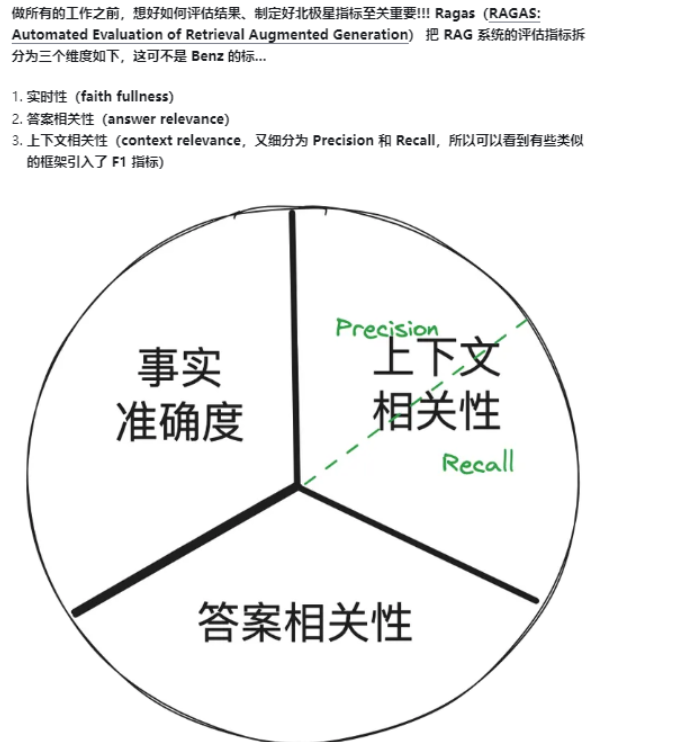

In [ ]:
#Introducing RagasEvaluatorChain:

#RagasEvaluatorChain creates a wrapper around the metrics ragas provides (documented here), 
#making it easier to run these evaluation with langchain and langsmith.

#The evaluator chain has the following APIs

#__call__(): call the RagasEvaluatorChain directly on the result of a QA chain.

#evaluate(): evaluate on a list of examples (with the input queries) and predictions (outputs from the QA chain).

#evaluate_run(): method implemented that is called by langsmith evaluators to evaluate langsmith datasets.

In [35]:
from ragas.langchain.evalchain import RagasEvaluatorChain
from ragas.metrics import (
    faithfulness,
    answer_relevancy,
    context_precision,
    context_recall,
)

# create evaluation chains(評估正確性, 提問-答案相關, 上下文相關-recall/precise...)
faithfulness_chain = RagasEvaluatorChain(metric=faithfulness)
answer_rel_chain = RagasEvaluatorChain(metric=answer_relevancy)
context_rel_chain = RagasEvaluatorChain(metric=context_precision)
context_recall_chain = RagasEvaluatorChain(metric=context_recall)

* #### Faithfulness

In [36]:
## check 
query = examples[1]["query"]

result = qa.invoke({"query": query})
result['result']

'根據文檔中提到的內容，預立醫療決定書中需要至少一名見證人。見證人的作用是確認簽署者的身分和心智能力，以確保簽署是自願的。見證人應該是成年人且無利害關係的第三方，可以是親友或專業人士。見證人的簽名和聯絡方式也應詳細記載在預立醫療決定書上，以確保文件的有效性。'

In [37]:
## Faithfulness
eval_result = faithfulness_chain(result)
eval_result["faithfulness_score"]

C:\Users\Jorge\anaconda3\envs\pytotch\lib\site-packages\langchain_core\_api\deprecation.py:117: LangChainDeprecationWarning: The function `__call__` was deprecated in LangChain 0.1.0 and will be removed in 0.2.0. Use invoke instead.
  warn_deprecated(


0.5

In [40]:
## 評估結果, 含原始內容
eval_result

{'query': '根據文檔中提到的內容，預立醫療決定書中需要多少名見證人？他們的作用是什麼？',
 'result': '根據文檔中提到的內容，預立醫療決定書中需要至少一名見證人。見證人的作用是確認簽署者的身分和心智能力，以確保簽署是自願的。見證人應該是成年人且無利害關係的第三方，可以是親友或專業人士。見證人的簽名和聯絡方式也應詳細記載在預立醫療決定書上，以確保文件的有效性。',
 'source_documents': [Document(page_content='預立醫療決定書 易讀手冊  \n \n7 第二步：預立醫療決定書能幫助我  \n預立 \n提早、早一點  \n決定書  \n寫下一份自己決定的文件  醫療 \n生病時，  \n醫生幫你治療的方式  \n  預立醫療決定書  是什麼？', metadata={'page': 9, 'source': './Data_test/預立醫療資料\\預立醫療決定書易讀說明手冊_ 高齡認知友善版_20230107.pdf'}),
  Document(page_content='18 預立醫療決定書 易讀手冊  \n \n讓每個                歲 的人 都可以自己寫   預立醫療決定書   18 \n輔助員提醒  \n《病人自主權利法》規定 18歲以上的成年人，且\n有心智能力才可以簽署「預立醫療決定書」喔！  \n民法已於 112年修改成年為 18歲以上。  你超過 18歲了就能寫了喔！  \n讓我們一起來認識  預立醫療決定書  吧 !  2019 年政府推動了《病人自主權利法》的規定  \n你現在幾歲了？  來看看  預立醫療決定書  是什麼樣子？  \n18歲 \n 40歲   65歲   10歲', metadata={'page': 20, 'source': './Data_test/預立醫療資料\\預立醫療決定書易讀說明手冊_ 高齡認知友善版_20230107.pdf'}),
  Document(page_content='療委任代理人委任書」 。  \n \n \n步驟四：預立醫療決定的生效  \n醫院將協助掃描、上傳您的預立醫療決定書，到中央主管機關資料庫，並註記在\n健保卡，這樣才算完成您的預立醫療決定。您所上傳至中央主管機關資料庫的預\n立醫療決定掃描檔，與正本效力相

* #### answer_relevancy

In [41]:
## answer_rel_chain, answer_relevancy_score

eval_result = answer_rel_chain(result)
eval_result["answer_relevancy_score"]

0.9578621765043701

* #### Context Recall

In [44]:
## Context Recall

result['ground_truths'] = examples[1]['answer']

## result須包含 ground_truths, context_recall_chain 才能使用

In [45]:
examples[1]['answer']

'預立醫療決定書需要2個18歲以上的見證人。他們的作用是確定簽署者是自願簽署，並證明沒有人強迫他們簽署這份決定書。如果找不到2個見證人，也可以去法院找公證人。'

In [46]:
eval_result = context_recall_chain(result)
eval_result["context_recall_score"]

1.0

In [47]:
eval_result

{'query': '根據文檔中提到的內容，預立醫療決定書中需要多少名見證人？他們的作用是什麼？',
 'result': '根據文檔中提到的內容，預立醫療決定書中需要至少一名見證人。見證人的作用是確認簽署者的身分和心智能力，以確保簽署是自願的。見證人應該是成年人且無利害關係的第三方，可以是親友或專業人士。見證人的簽名和聯絡方式也應詳細記載在預立醫療決定書上，以確保文件的有效性。',
 'source_documents': [Document(page_content='預立醫療決定書 易讀手冊  \n \n7 第二步：預立醫療決定書能幫助我  \n預立 \n提早、早一點  \n決定書  \n寫下一份自己決定的文件  醫療 \n生病時，  \n醫生幫你治療的方式  \n  預立醫療決定書  是什麼？', metadata={'page': 9, 'source': './Data_test/預立醫療資料\\預立醫療決定書易讀說明手冊_ 高齡認知友善版_20230107.pdf'}),
  Document(page_content='18 預立醫療決定書 易讀手冊  \n \n讓每個                歲 的人 都可以自己寫   預立醫療決定書   18 \n輔助員提醒  \n《病人自主權利法》規定 18歲以上的成年人，且\n有心智能力才可以簽署「預立醫療決定書」喔！  \n民法已於 112年修改成年為 18歲以上。  你超過 18歲了就能寫了喔！  \n讓我們一起來認識  預立醫療決定書  吧 !  2019 年政府推動了《病人自主權利法》的規定  \n你現在幾歲了？  來看看  預立醫療決定書  是什麼樣子？  \n18歲 \n 40歲   65歲   10歲', metadata={'page': 20, 'source': './Data_test/預立醫療資料\\預立醫療決定書易讀說明手冊_ 高齡認知友善版_20230107.pdf'}),
  Document(page_content='療委任代理人委任書」 。  \n \n \n步驟四：預立醫療決定的生效  \n醫院將協助掃描、上傳您的預立醫療決定書，到中央主管機關資料庫，並註記在\n健保卡，這樣才算完成您的預立醫療決定。您所上傳至中央主管機關資料庫的預\n立醫療決定掃描檔，與正本效力相

* #### context relevancy/precision

In [48]:
## context relevancy/precision

eval_result = context_rel_chain(result)
eval_result["context_precision_score"]

0.0

* ### 比對範例與模型生成結果的正確性
* #### Evaluate a list of inputs/queries and the outputs/predictions from the QA chain.

In [38]:
# run the queries as a batch for efficiency
predictions = qa.batch(examples)

# evaluate
print("evaluating...")
r = faithfulness_chain.evaluate(examples, predictions)
r

evaluating...


100%|████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:31<00:00, 15.69s/it]


[{'faithfulness_score': 1.0},
 {'faithfulness_score': 1.0},
 {'faithfulness_score': 0.8333333333333334},
 {'faithfulness_score': 0.0},
 {'faithfulness_score': 1.0},
 {'faithfulness_score': 0.7142857142857143},
 {'faithfulness_score': 0.0},
 {'faithfulness_score': 1.0},
 {'faithfulness_score': 1.0},
 {'faithfulness_score': 0.3333333333333333},
 {'faithfulness_score': 0.6},
 {'faithfulness_score': 0.6666666666666666},
 {'faithfulness_score': 0.6},
 {'faithfulness_score': 1.0},
 {'faithfulness_score': 0.8},
 {'faithfulness_score': 1.0},
 {'faithfulness_score': 1.0},
 {'faithfulness_score': 0.6666666666666666},
 {'faithfulness_score': 0.6666666666666666}]

* ### evaluate context 相關性

In [49]:
examples = [{"ground_truths": item["answer"], **item} for item in examples]

examples

[{'ground_truths': "The source of the document is './Data_test/預立醫療資料\\\\預立醫療照護諮商說明工具(意願人版).pdf' as indicated in the metadata.",
  'query': 'What is the source of the document provided in the metadata?',
  'answer': "The source of the document is './Data_test/預立醫療資料\\\\預立醫療照護諮商說明工具(意願人版).pdf' as indicated in the metadata."},
 {'ground_truths': '預立醫療決定書需要2個18歲以上的見證人。他們的作用是確定簽署者是自願簽署，並證明沒有人強迫他們簽署這份決定書。如果找不到2個見證人，也可以去法院找公證人。',
  'query': '根據文檔中提到的內容，預立醫療決定書中需要多少名見證人？他們的作用是什麼？',
  'answer': '預立醫療決定書需要2個18歲以上的見證人。他們的作用是確定簽署者是自願簽署，並證明沒有人強迫他們簽署這份決定書。如果找不到2個見證人，也可以去法院找公證人。'},
 {'ground_truths': '這份文件提到了「預立醫療決定書 (AD)」，其縮寫為AD。',
  'query': '在這份文件中，提到了哪個重要的文件？這個文件的縮寫是什麼？',
  'answer': '這份文件提到了「預立醫療決定書 (AD)」，其縮寫為AD。'},
 {'ground_truths': '根據文件中提到的內容，極重度失智症中所描述的5種生病情況包括政府公告的疾病以及無法治好的疾病，例如：1. 罕見疾病 2. 漸凍人 3. 小腦萎縮症 4. 泡泡龍。',
  'query': '根據文件中提到的內容，請列舉出極重度失智症中所描述的5種生病情況是什麼？',
  'answer': '根據文件中提到的內容，極重度失智症中所描述的5種生病情況包括政府公告的疾病以及無法治好的疾病，例如：1. 罕見疾病 2. 漸凍人 3. 小腦萎縮症 4. 泡泡龍。'},
 {'ground_truths': '滿20歲具有完全行為

In [50]:
# evaluate context 相關性

print("evaluating...")
r = context_rel_chain.evaluate(examples, predictions)
r

evaluating...


100%|████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:09<00:00,  4.98s/it]


[{'context_precision_score': 0.3333333333},
 {'context_precision_score': 0.0},
 {'context_precision_score': 0.0},
 {'context_precision_score': 0.0},
 {'context_precision_score': 0.0},
 {'context_precision_score': 0.49999999995},
 {'context_precision_score': 0.0},
 {'context_precision_score': 0.9999999999},
 {'context_precision_score': 0.3333333333},
 {'context_precision_score': 0.0},
 {'context_precision_score': 0.0},
 {'context_precision_score': 0.0},
 {'context_precision_score': 0.0},
 {'context_precision_score': 0.0},
 {'context_precision_score': 0.0},
 {'context_precision_score': 0.0},
 {'context_precision_score': 0.0},
 {'context_precision_score': 0.0},
 {'context_precision_score': 0.0}]

In [ ]:
### 以上出問題, 改原始碼?

## 評估 II
* ### openAI moderation

In [60]:
## moderation for query
from openai import OpenAI
client = OpenAI()

query = eval_queries[1]
# openAI response for input query
response = client.moderations.create(input=query)
moderation_output = response.results[0]

flag = moderation_output.flagged
flag

False

In [61]:
# check categories(all), 取得 moderation的結果
moderation_categories = moderation_output.categories

# 打印字典中的所有 key pair, openAI 提供的危害事項...
for key, value in moderation_categories:
    print(f"{key}: {value}")


harassment: False
harassment_threatening: False
hate: False
hate_threatening: False
self_harm: False
self_harm_instructions: False
self_harm_intent: False
sexual: False
sexual_minors: False
violence: False
violence_graphic: False
self-harm: False
sexual/minors: False
hate/threatening: False
violence/graphic: False
self-harm/intent: False
self-harm/instructions: False
harassment/threatening: False


In [62]:
## check all category_scores, harassment:騷擾
moderation_scores = moderation_output.category_scores
for key, value in moderation_scores:
    print(f"{key}: {value}")


harassment: 4.112939859624021e-05
harassment_threatening: 3.41531922458671e-05
hate: 1.922586488944944e-05
hate_threatening: 1.5450287946805474e-06
self_harm: 2.796359513013158e-05
self_harm_instructions: 6.199437621035031e-07
self_harm_intent: 1.916689143399708e-06
sexual: 4.097480541531695e-06
sexual_minors: 1.7869514294943656e-06
violence: 0.00033890592749230564
violence_graphic: 0.0002624426851980388
self-harm: 2.796359513013158e-05
sexual/minors: 1.7869514294943656e-06
hate/threatening: 1.5450287946805474e-06
violence/graphic: 0.0002624426851980388
self-harm/intent: 1.916689143399708e-06
self-harm/instructions: 6.199437621035031e-07
harassment/threatening: 3.41531922458671e-05


In [63]:
## check category_scores, harassment:騷擾
moderation_output.category_scores.harassment

4.112939859624021e-05

* ### output Check, 使用 langkit

In [107]:
## response check, 使用 langkit; 
## OpenAI
from langkit.openai import OpenAIDefault
import os
#os.environ["OPENAI_API_KEY"] = "<your-openai-key>"

from langkit import llm_metrics
from langkit import extract
from langkit import response_hallucination

## langkit schema
schema = llm_metrics.init()                                                 ## 首次載入費時, load nltk_data...

llm = OpenAIDefault(model="gpt-3.5-turbo")
response_hallucination.init(llm=llm, num_samples=2)                         ## 1 or 2 looks ok


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Jorge\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [75]:
## Langkit prompt/response assign
prompt = query
response = result["result"]

langkit = extract({"prompt":prompt, "response":response}, schema=schema) 

In [70]:
response

'A：滿 20歲具有完全行為能力者皆可，只要您：至醫療機構完成「預立醫療照護諮商」，並經兩人以上在場見證或公證程序。完成健保 IC卡註記，您的「預立醫療決定」即具有法律效力。'

In [76]:
langkit

{'prompt': '任何人都可以進行「預立醫療照護諮商」 及「預立醫療決定」嗎？',
 'response': 'A：滿 20歲具有完全行為能力者皆可，只要您：至醫療機構完成「預立醫療照護諮商」，並經兩人以上在場見證或公證程序。完成健保 IC卡註記，您的「預立醫療決定」即具有法律效力。',
 'prompt.sentiment_nltk': 0.0,
 'response.sentiment_nltk': 0.0,
 'prompt.flesch_reading_ease': 120.21,
 'response.flesch_reading_ease': 119.19,
 'prompt.automated_readability_index': 47.9,
 'response.automated_readability_index': 112.0,
 'prompt.aggregate_reading_level': 0.0,
 'response.aggregate_reading_level': 1.0,
 'prompt.syllable_count': 2,
 'response.syllable_count': 3,
 'prompt.lexicon_count': 2,
 'response.lexicon_count': 3,
 'prompt.sentence_count': 1,
 'response.sentence_count': 1,
 'prompt.character_count': 29,
 'response.character_count': 84,
 'prompt.letter_count': 24,
 'response.letter_count': 73,
 'prompt.polysyllable_count': 0,
 'response.polysyllable_count': 0,
 'prompt.monosyllable_count': 2,
 'response.monosyllable_count': 3,
 'prompt.difficult_words': 0,
 'response.difficult_words': 0,
 'prompt.jailbreak_similarity': 0.2

In [77]:
hallucination = lankit['response.hallucination']                           ## 需 init response.hallucination
relevance_to_prompt = lankit['response.relevance_to_prompt']
response_toxicity = lankit['response.toxicity']

In [78]:
print(hallucination), print(relevance_to_prompt), print(response_toxicity) 

0.5791069269180298
0.8103093504905701
0.0015923380851745605


(None, None, None)

In [108]:
## check consistency
consistency = response_hallucination.consistency_check(
    prompt= prompt,
    response= response,
)

consistency

{'llm_score': 1.0,
 'semantic_score': 0.23139223456382751,
 'final_score': 0.6156961172819138,
 'total_tokens': 1330,
 'samples': ['根據許多國家的法律和規定，通常只有符合特定資格和條件的人或單位才可以進行「預立醫療照護諮商」和「預立醫療決定」。常見的資格包括醫療專業人員、法律代表或指定代理人。這些人通常需要接受相關培訓或認證，以確保他們具備適當的知識和技能來代表他人做出醫療決定。\n\n如果您有進一步的問題或需要更詳細的資訊，請考慮諮詢當地的法律專家或醫療專業人士。',
  '根據大多數國家的法律，任何成年人都有權利進行預先醫療諮詢和做出預先醫療決定。這包括但不限於撰寫生前醫療指示、指定醫療代理人等。然而，為了確保合法性和可執行性，可能需要遵循特定的程序和要求。建議您諮詢專業法律顧問以了解您所在地區的具體法律規定。'],
 'response': 'A：滿 20歲具有完全行為能力者皆可，只要您：至醫療機構完成「預立醫療照護諮商」，並經兩人以上在場見證或公證程序。完成健保 IC卡註記，您的「預立醫療決定」即具有法律效力。'}

In [109]:
print("semantic: ", consistency["semantic_score"], "\nFinal Score for consistency: ", consistency["final_score"])

semantic:  0.23139223456382751 
Final Score for consistency:  0.6156961172819138


### 用以 huggingface evaluate: Bert score/bleu score 評估

In [81]:
## 評估用套件...
# huggingface evaluate 
import evaluate

* ### Bert score

In [83]:
## load the Bert score module and then we can call it with a prompt and response:
bertscore = evaluate.load("bertscore")

In [ ]:
#高 BERT 分數表示反應在語義上與提示相似，表明模型已產生相關且上下文適當的答案。
#相反，低 BERT 分數表示反應在語義上與提示不相似，表示模型產生了不相關且上下文不恰當的答案。

In [101]:
bert_score = bertscore.compute(
            predictions=[query],
            references=[response],
            model_type="distilbert-base-uncased",
        )

bert_score

{'precision': [0.9557525515556335],
 'recall': [0.9216774106025696],
 'f1': [0.9384057521820068],
 'hashcode': 'distilbert-base-uncased_L5_no-idf_version=0.3.12(hug_trans=4.29.2)'}

In [102]:
bert_score = bert_score["f1"][0]
bert_score 

0.9384057521820068

* ### BLEU 文字匹配程度

In [95]:
## BLEU 文字匹配程度
import evaluate
bleu = evaluate.load("bleu")

In [96]:
bleu_score = bleu.compute(predictions=[query], 
             references=[response], 
             max_order=2)

bleu_score

{'bleu': 0.0,
 'precisions': [0.0, 0.0],
 'brevity_penalty': 0.6065306597126334,
 'length_ratio': 0.6666666666666666,
 'translation_length': 2,
 'reference_length': 3}

In [97]:
bleu_score = bleu_score["bleu"]
bleu_score

0.0

* ### 以Bleu 及 Bert 分數評估幻覺; prompt 與responde 的關係, 或許比較 response 更好? (langkit llm 方式?)

In [106]:
hallucination_score = ((1-bleu_score) + (1- bert_score)) / 2
hallucination_score

0.5307971239089966